# Chapter 4 - Building Models with Distance Metrics and Nearest Neighbors

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_4) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Understanding k-nearest neighbors (KNN)](#understanding-k-nearest-neighbors-knn)
- [Distance Metrics Overview](#distance-metrics-overview)
- [Hyperparameter Tuning in KNN](#hyperparameter-tuning-in-knn)
- [Evaluating KNN Performance](#evaluating-knn-performance)
- [Practical Exercises with KNN Models](#practical-exercises-with-knn-models)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Understanding k-nearest neighbors (KNN)

KNN menyimpan pengamatan training dan mencari $k$ tetangga terdekat saat prediksi. Klasifikasi memakai voting, sedangkan regresi memakai rata-rata respons tetangga. Bobot distance memberi kontribusi lebih besar pada tetangga dekat. Nilai k kecil lebih fleksibel dan rentan noise; k besar menghaluskan prediksi tetapi dapat meningkatkan bias. Metode ini nonparametrik, namun tetap bergantung pada relevansi fitur, representasi, dan asumsi kemiripan.

Contoh dasar memakai Iris dengan empat fitur dan tiga kelas. Split memisahkan training/test; scaling ditambahkan di pipeline agar jarak dipelajari dalam satuan yang sebanding.

In [2]:
# Load libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

In [3]:
# Load libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and train a basic KNN model
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

iris_baseline_accuracy = accuracy_score(y_test, y_pred)

Accuracy: 0.9333333333333333


## Distance Metrics Overview

Minkowski adalah $d_p(x,z)=(\sum_j|x_j-z_j|^p)^{1/p}$. Euclidean memakai p=2, Manhattan p=1; Minkowski default p=2 sama dengan Euclidean. Cosine distance membandingkan arah vektor, sedangkan Mahalanobis mempertimbangkan kovarians. Pilihan metrik mengikuti arti fitur, bukan nama algoritma saja.

Dataset lingkaran dan checkerboard memberi ilustrasi batas keputusan. Variabel sumber bernama moons sebenarnya checkerboard, bukan dataset make_moons. Accuracy satu split tidak membuktikan Manhattan atau Euclidean selalu unggul. Pada dimensi tinggi, konsentrasi jarak mengurangi makna tetangga; KD-tree/Ball-tree dapat membantu pencarian pada kondisi tertentu, sementara brute force tetap berguna pada dimensi tinggi.

In [4]:
# Load libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create two synthetic datasets that highlight metric differences
n_samples = 300

# Circular dataset with high noise (Euclidean distance should work better)
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3, random_state=2024)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Checkerboard pattern dataset (Manhattan distance should work better)
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

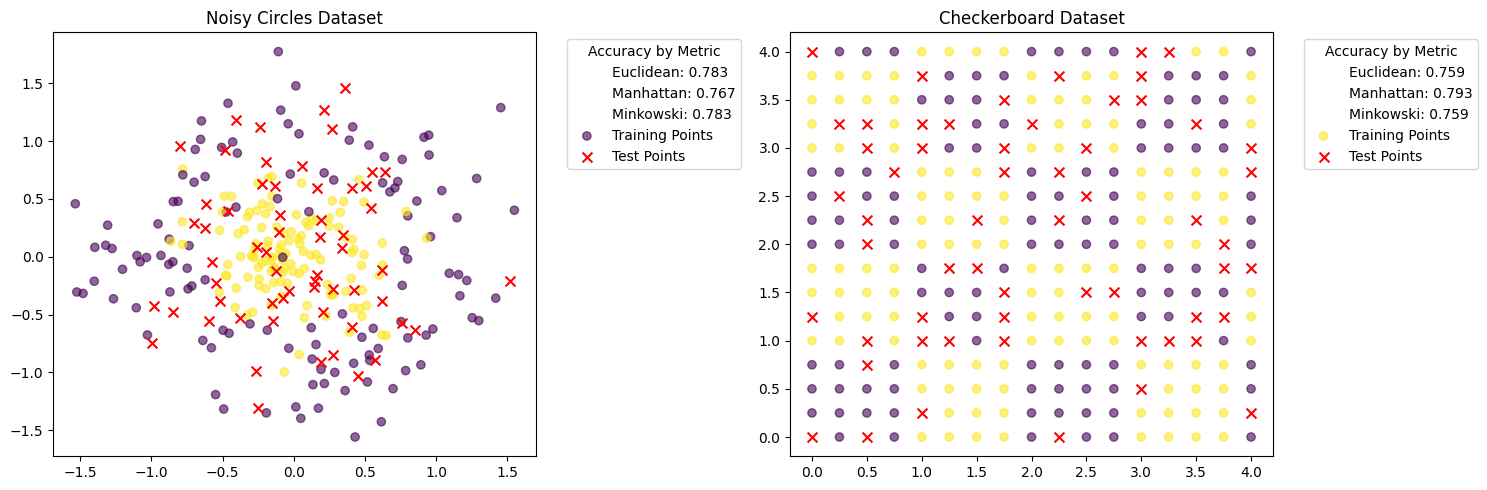

In [5]:
# Compare different distance metrics on both datasets
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Test on "circles" dataset
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)

    # Test on "moons" dataset
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Set up plot specs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot circles dataset
scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1], c=y_circles_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax1.set_title('Noisy Circles Dataset')

# Create dummy lines for legend
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(lines1 + [scatter1_train, scatter1_test], legend_text1 + ['Training Points', 'Test Points'], 
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot moons dataset
scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1], c=y_moons_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax2.set_title('Checkerboard Dataset')

# Create dummy lines for legend
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(lines2 + [scatter2_train, scatter2_test], legend_text2 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning in KNN

GridSearchCV mencoba kombinasi k, bobot, dan metrik menggunakan lima fold training. StandardScaler berada di pipeline agar setiap fold tidak memakai statistik validation. Best score adalah skor cross-validation untuk konfigurasi yang dipilih dalam grid, bukan jaminan optimum global atau skor test yang independen.

In [6]:
# Load libraries
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier
knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

# Define parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

# Create grid search
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy'
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

iris_grid_cv_accuracy = grid_search.best_score_
iris_best_pipeline = grid_search.best_estimator_

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Best cross-validation score: 0.9833333333333334


## Evaluating KNN Performance

Learning curve membandingkan skor training/validation pada ukuran training yang meningkat. Celah besar dapat menandakan variance tinggi; dua skor rendah dapat menunjukkan bias atau fitur kurang informatif. Confusion matrix menyatakan jumlah prediksi tiap kelas; precision mengukur ketepatan prediksi kelas dan recall cakupan kelas sebenarnya. F1 adalah harmonic mean keduanya. Macro average memberi bobot sama pada kelas, weighted average mengikuti support.

Skor CV setelah memilih hyperparameter pada fold yang sama bersifat deskriptif dan dapat optimistis; nested CV diperlukan untuk evaluasi pemilihan yang lebih independen. Accuracy 100% pada satu kelas test kecil bukan bukti overfitting dengan sendirinya.

In [7]:
# Load libraries
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

Cross-validation scores: [0.95833333 0.95833333 1.         1.         1.        ]
Mean CV score: 0.9833333333333334
Standard deviation: 0.020412414523193135


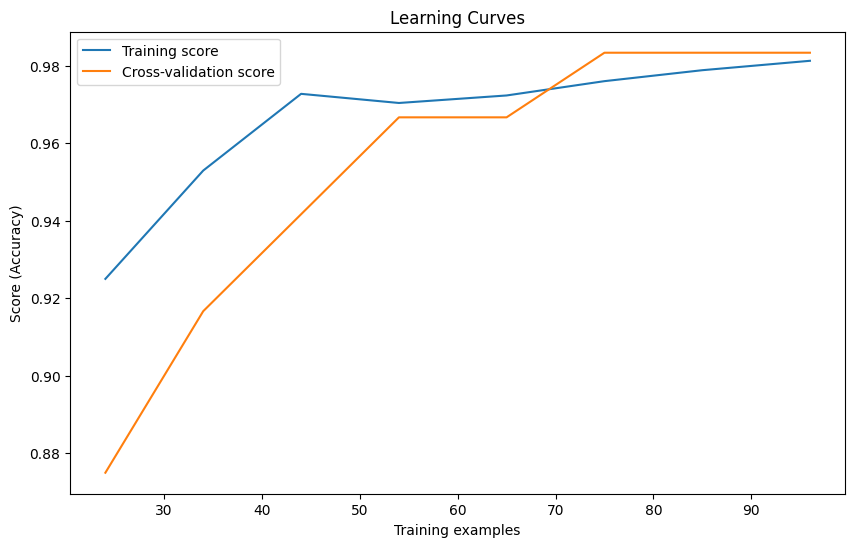

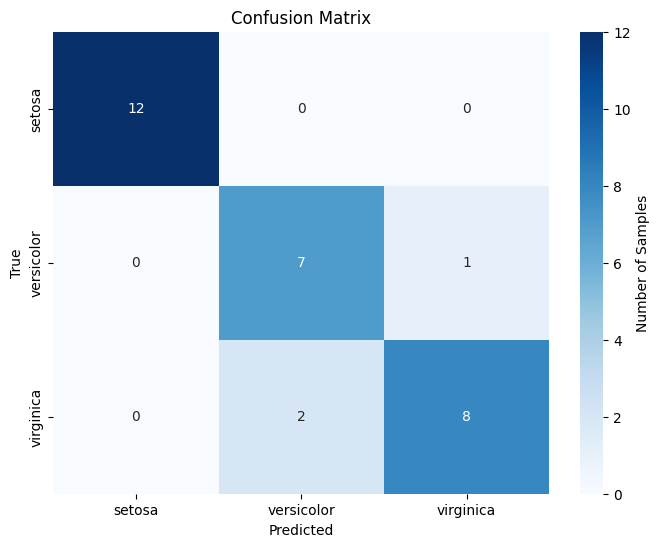


Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.778,0.875,0.824,8
virginica,0.889,0.800,0.842,10
accuracy,0.900,0.900,0.900,1
macro avg,0.889,0.892,0.889,30
weighted avg,0.904,0.900,0.900,30


In [8]:
# Get cross-validation scores
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.25, 1.0, 8),
    cv=5
)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

# Make predictions on test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Get class names from iris dataset
class_names = iris.target_names

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Get classification report as a dict
report_dict = classification_report(y_test, y_pred, 
                                  target_names=class_names,
                                  output_dict=True)

# Create a DataFrame for better visualization
report_df = pd.DataFrame(report_dict).transpose()

# Style the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print("\nClassification Report:")
display(styled_df)

iris_grid_test_accuracy = accuracy_score(y_test, y_pred)
iris_cm = cm.copy()
iris_test_target = y_test.copy()

## Practical Exercises with KNN Models

Tiga latihan selesai: klasifikasi Breast Cancer, tuning KNN pada data sintetis tiga kelas, dan evaluasi pada dataset sintetis lain dengan confusion matrix. Scaling untuk grid search dilakukan di pipeline pada setiap fold. Metrik menggambarkan split masing-masing dan tidak menjadi dasar klaim klinis atau performa semua dataset.

### Latihan 1: Building a KNN Classifier

KNN Breast Cancer memakai StandardScaler dari training dan lima tetangga. Classification report menunjukkan kesalahan pada kedua kelas di samping accuracy.

In [9]:
# Load libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load the Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Preprocess the Data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cancer_exercise_accuracy = accuracy

Accuracy: 0.947

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Latihan 2: Tuning Hyperparameters with Grid Search

Data sintetis tiga kelas digunakan untuk mencoba kombinasi k, bobot, dan metrik. Scaler berada dalam pipeline grid search sehingga dipelajari kembali pada setiap fold.

In [10]:
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load a different dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                         n_redundant=5, n_classes=3, random_state=42)

# Preprocess the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up grid search:
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}
knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train, y_train)

# Evaluate best model
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
y_pred = grid_search.predict(X_test)
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best cross-validation score: 0.85625

Test Set Performance:
Accuracy: 0.865

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        70
           1       0.88      0.92      0.90        73
           2       0.80      0.82      0.81        57

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.87      0.86      0.87       200



### Latihan 3 Evaluating a KNN Classifier

Dataset sintetis 15 fitur digunakan untuk menghitung accuracy, confusion matrix, dan classification report. Tiga output memberi rincian jenis kesalahan, bukan hanya skor agregat.

In [11]:
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Dataset
# Create a synthetic dataset with 3 classes and some informative/redundant features
X, y = make_classification(n_samples=1000, 
                         n_features=15, 
                         n_informative=10,
                         n_redundant=5, 
                         n_classes=3,
                         n_clusters_per_class=2,
                         random_state=42)

# Preprocess the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
print("Model Performance Evaluation")
print("-" * 30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance Evaluation
------------------------------
Accuracy Score: 0.850

Confusion Matrix:
[[56  6  6]
 [ 4 56  5]
 [ 6  3 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        68
           1       0.86      0.86      0.86        65
           2       0.84      0.87      0.85        67

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [12]:
chapter_results = {'iris_baseline_accuracy': float(iris_baseline_accuracy),
 'iris_grid_cv_accuracy': float(iris_grid_cv_accuracy),
 'iris_grid_test_accuracy': float(iris_grid_test_accuracy),
 'cancer_exercise_accuracy': float(cancer_exercise_accuracy)}
assert iris_cm.sum() == len(iris_test_target)
assert 'scaler' in iris_best_pipeline.named_steps
print(json.dumps(chapter_results, indent=2))

{
  "iris_baseline_accuracy": 0.9333333333333333,
  "iris_grid_cv_accuracy": 0.9833333333333334,
  "iris_grid_test_accuracy": 0.9,
  "cancer_exercise_accuracy": 0.9473684210526315
}


## Ringkasan Bab

KNN dasar Iris dengan scaling menghasilkan **accuracy test 93.33%**. Grid search menghasilkan best CV score **98.33%**, tetapi accuracy test konfigurasi terpilih **90.00%**. Jadi skor CV yang tinggi tidak menjamin perbaikan pada setiap holdout kecil. Confusion matrix menunjukkan jenis salah klasifikasi, bukan hanya skor agregat.

Euclidean sama dengan Minkowski default p=2; Manhattan menggunakan p=1. Bentuk checkerboard dan lingkaran menunjukkan bahwa metrik perlu disesuaikan dengan representasi data, bukan dianggap mempunyai pemenang universal. Scaling pada tuning berada di dalam pipeline agar tiap fold belajar sendiri. Latihan Breast Cancer menghasilkan **accuracy 94.74%** pada split latihan. Learning curve dan report membantu membaca perbedaan training/validation serta precision/recall kelas, dengan batas bahwa pemilihan hyperparameter juga memengaruhi estimasi CV.